In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Housing - Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.shape

(545, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


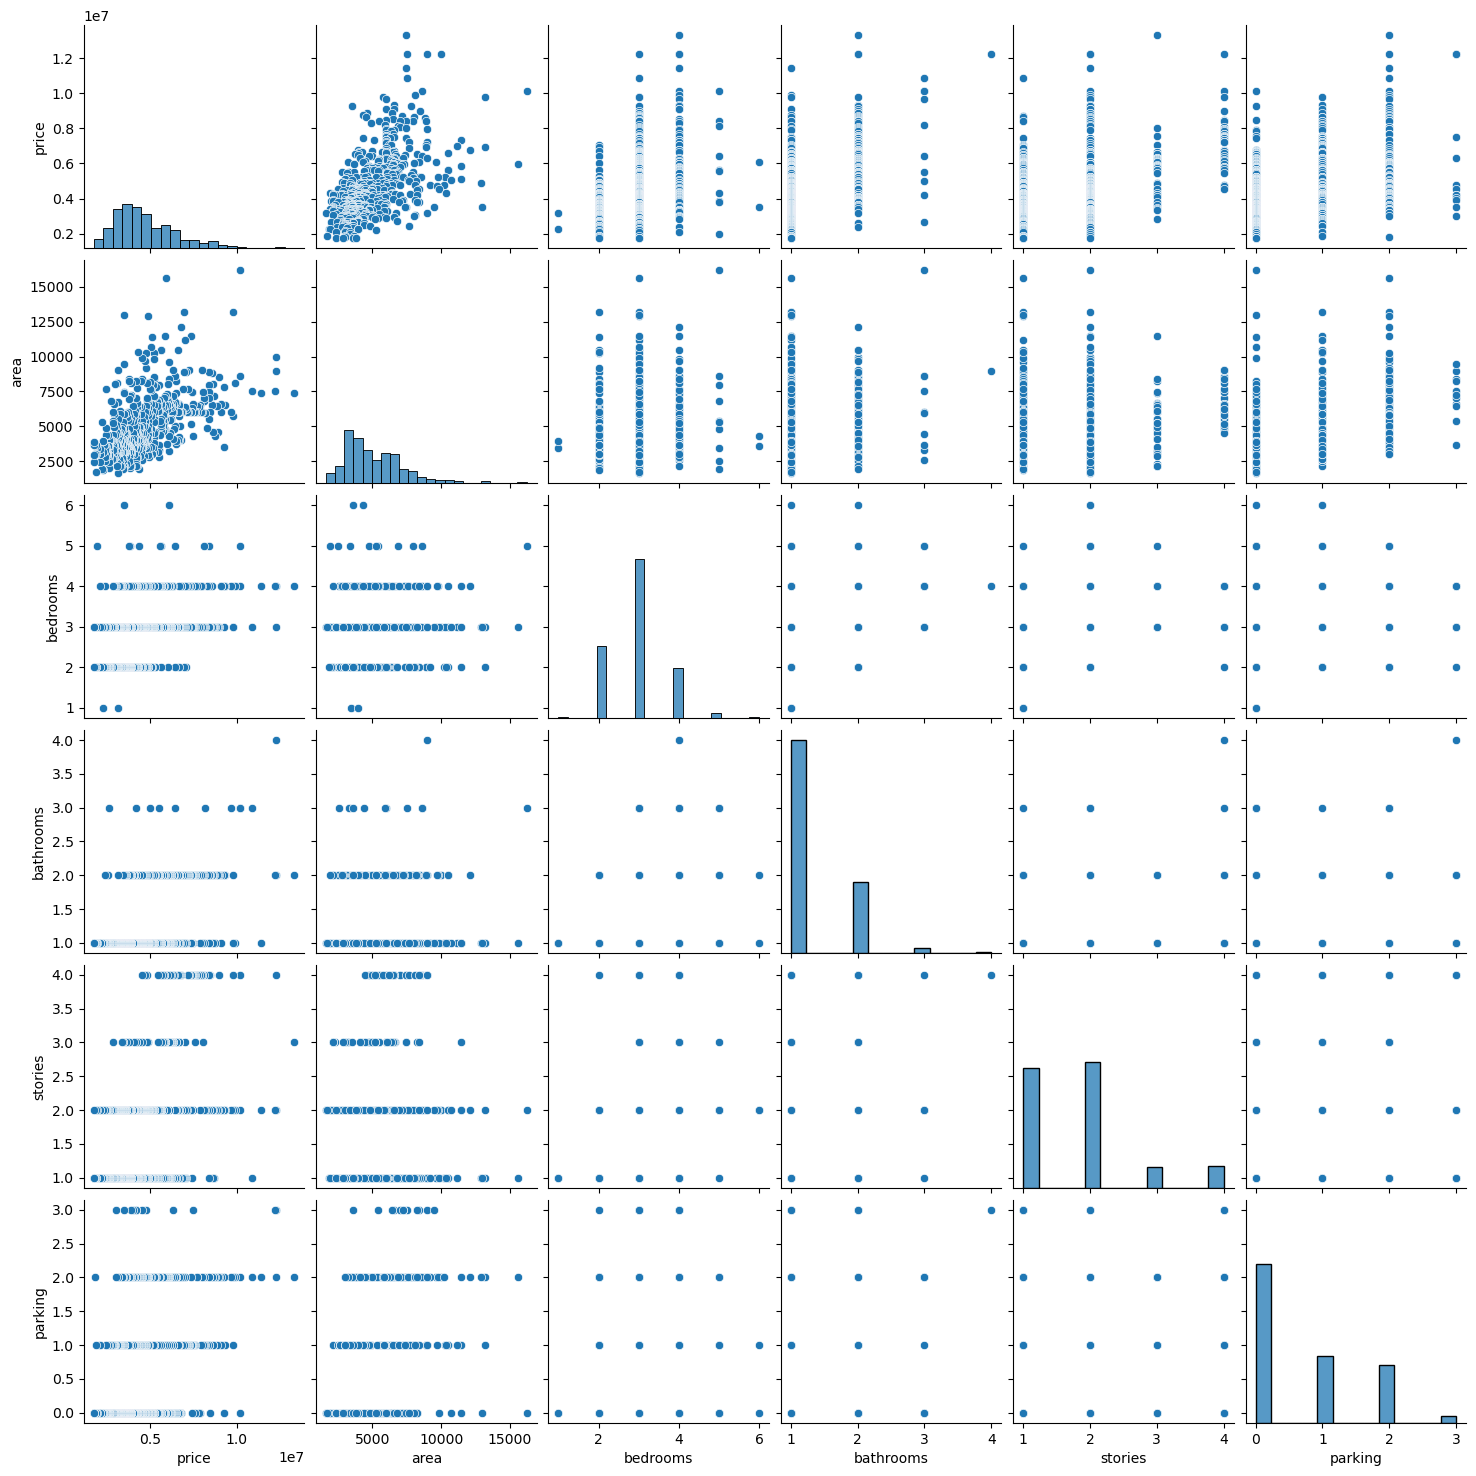

In [5]:
sns.pairplot(df)

<Axes: xlabel='prefarea', ylabel='price'>

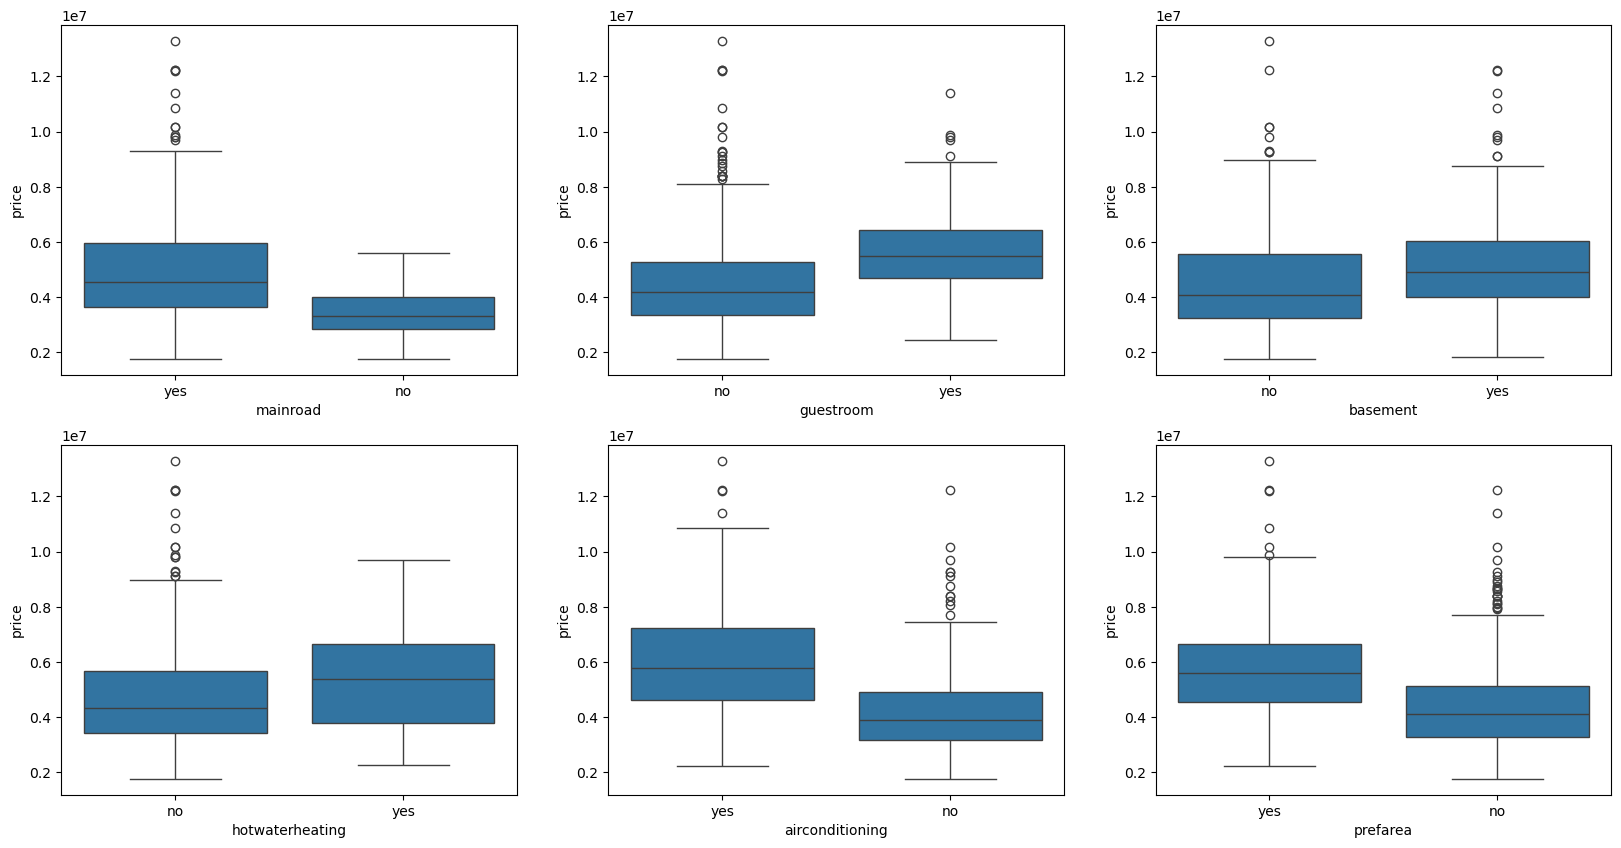

In [10]:
### Categorical Variable Analysis
plt.figure(figsize = (20,10))
plt.subplot(2,3,1)
sns.boxplot( x = 'mainroad', y = 'price', data = df )
plt.subplot(2,3,2)
sns.boxplot( x = 'guestroom', y = 'price', data = df )
plt.subplot(2,3,3)
sns.boxplot( x = 'basement', y = 'price', data = df )
plt.subplot(2,3,4)
sns.boxplot( x = 'hotwaterheating', y = 'price', data = df )
plt.subplot(2,3,5)
sns.boxplot( x = 'airconditioning', y = 'price', data = df )
plt.subplot(2,3,6)
sns.boxplot( x = 'prefarea', y = 'price', data = df )

<Axes: xlabel='furnishingstatus', ylabel='price'>

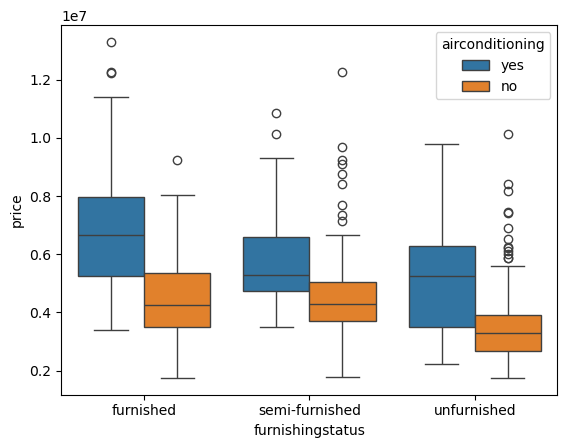

In [11]:
sns.boxplot(x = 'furnishingstatus', y = 'price', hue = 'airconditioning', data = df )

In [12]:
categorical  = ['guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'mainroad']

def binary_map (x):
  return x.map({'yes':1 , 'no': 0})

df[categorical] = df[categorical].apply(binary_map)

df[categorical].head()

,guestroom,basement,hotwaterheating,airconditioning,prefarea,mainroad
0,0,0,0,1,1,1
1,0,0,0,1,0,1
2,0,1,0,0,1,1
3,0,1,0,1,1,1
4,1,1,0,1,0,1


In [13]:
### Dummy variables

status = pd.get_dummies(df['furnishingstatus'], drop_first = True)

status.head()

,semi-furnished,unfurnished
0,False,False
1,False,False
2,True,False
3,False,False
4,False,False


In [14]:
df = pd.concat ([df,status], axis = 1)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,semi-furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished,False,False


In [15]:
df.drop(['furnishingstatus'], axis = 1, inplace = True)

In [16]:
#### Train - Test Split

from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, train_size = 0.70, test_size = 0.30, random_state = 100)

In [17]:
df_train.shape

(381, 14)

In [18]:
df_test.shape

(164, 14)

In [19]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 381 entries, 359 to 520
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   price            381 non-null    int64
 1   area             381 non-null    int64
 2   bedrooms         381 non-null    int64
 3   bathrooms        381 non-null    int64
 4   stories          381 non-null    int64
 5   mainroad         381 non-null    int64
 6   guestroom        381 non-null    int64
 7   basement         381 non-null    int64
 8   hotwaterheating  381 non-null    int64
 9   airconditioning  381 non-null    int64
 10  parking          381 non-null    int64
 11  prefarea         381 non-null    int64
 12  semi-furnished   381 non-null    bool 
 13  unfurnished      381 non-null    bool 
dtypes: bool(2), int64(12)
memory usage: 39.4 KB


In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

num_var = ['area','bedrooms',  'bathrooms','stories','parking', 'price' ]

df_train[num_var] = scaler.fit_transform(df_train[num_var])

In [21]:
df_train.describe()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
count,381.000000,381.000000,381.000000,381.000000,381.000000,381.000000,381.000000,381.000000,381.000000,381.000000,381.000000,381.000000
mean,0.260333,0.288710,0.386352,0.136483,0.268591,0.855643,0.170604,0.351706,0.052493,0.299213,0.242345,0.233596
std,0.157607,0.181420,0.147336,0.237325,0.295001,0.351913,0.376657,0.478131,0.223313,0.458515,0.285933,0.423674
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.151515,0.155227,0.200000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.221212,0.234424,0.400000,0.000000,0.333333,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.345455,0.398099,0.400000,0.500000,0.333333,1.000000,0.000000,1.000000,0.000000,1.000000,0.333333,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: >

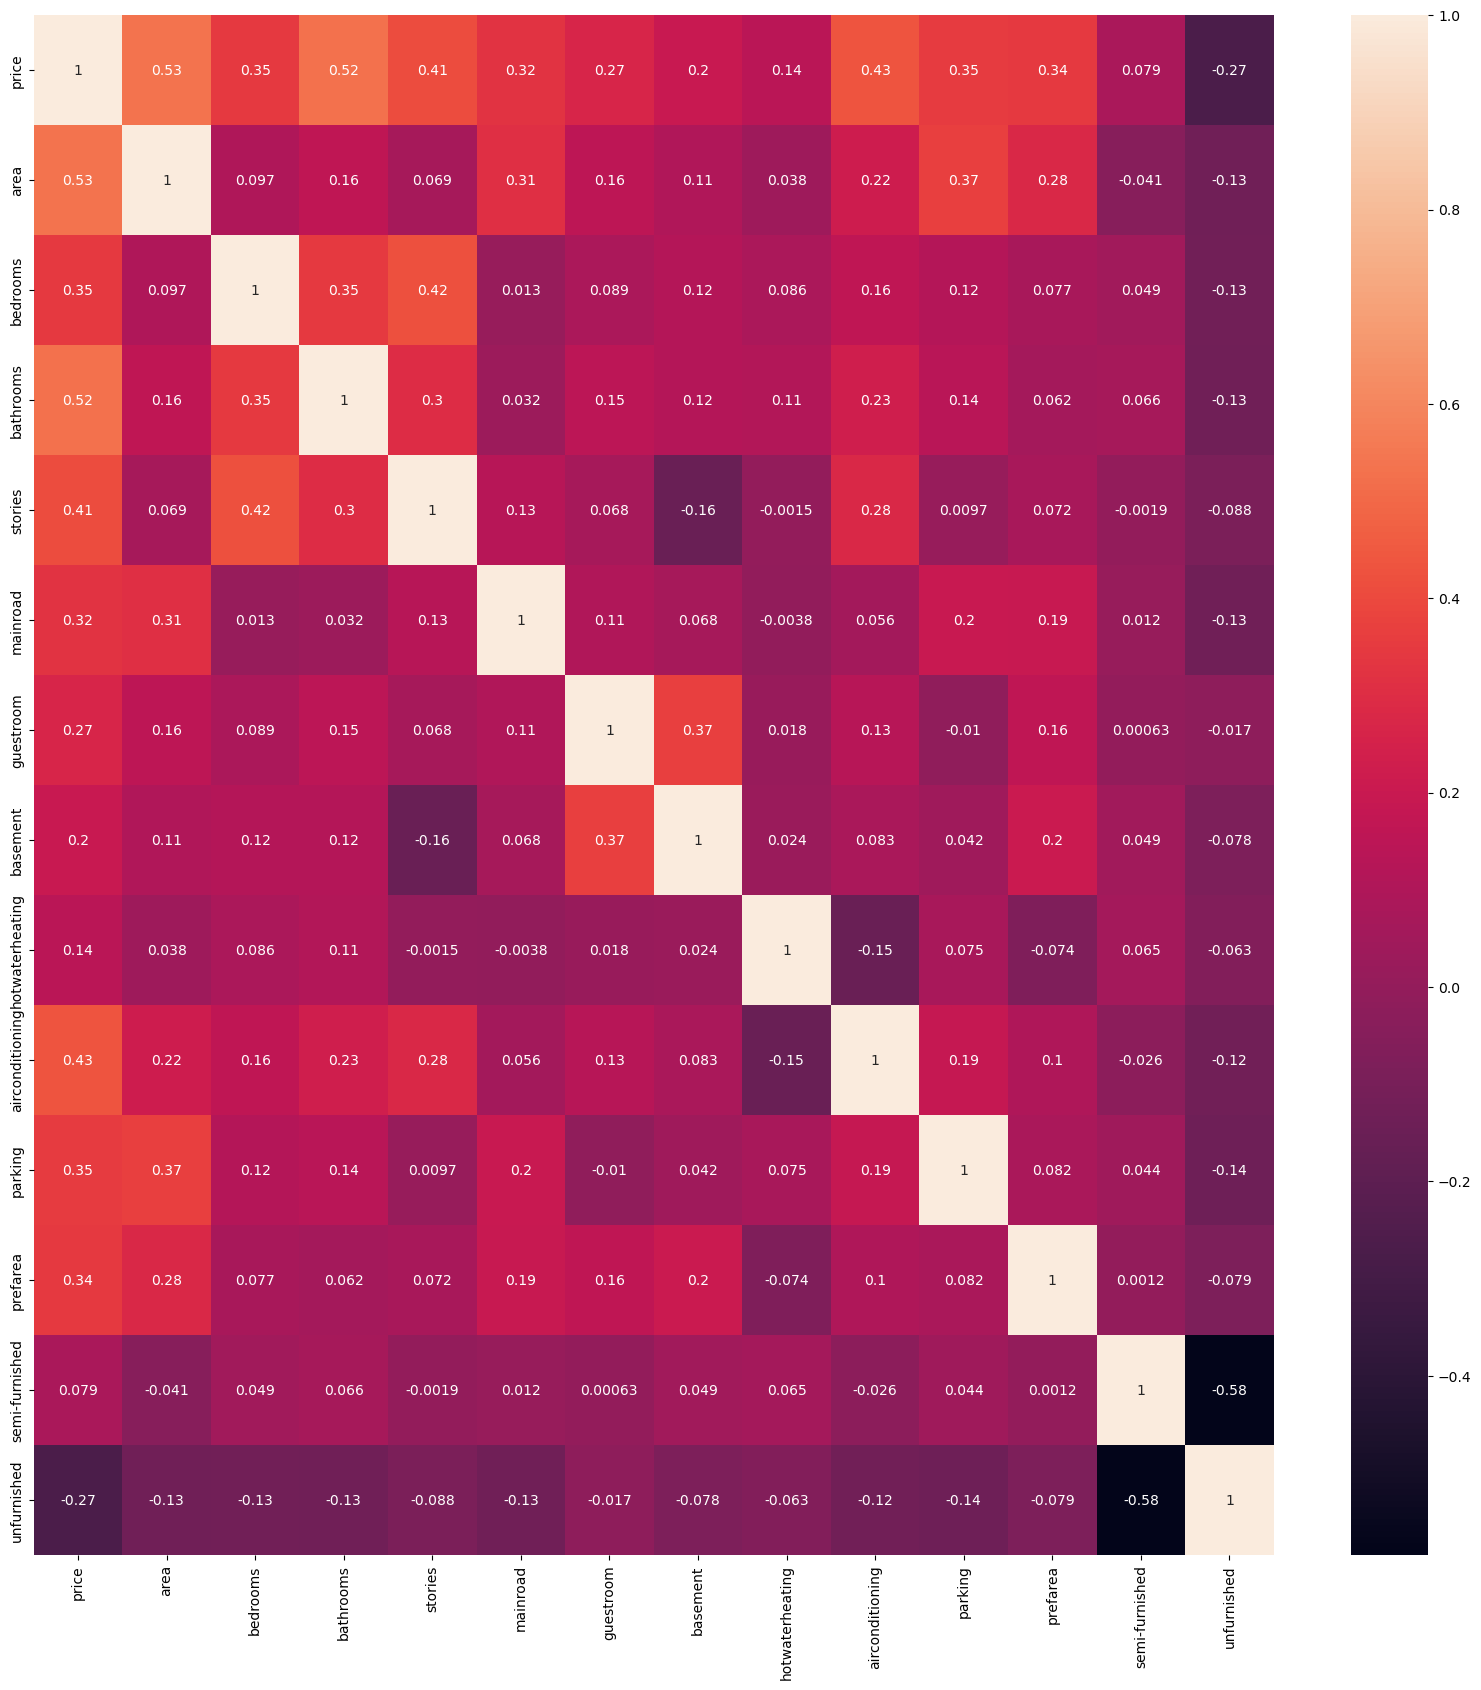

In [22]:
plt.figure(figsize = (20,20))
sns.heatmap(df_train.corr(), annot = True)

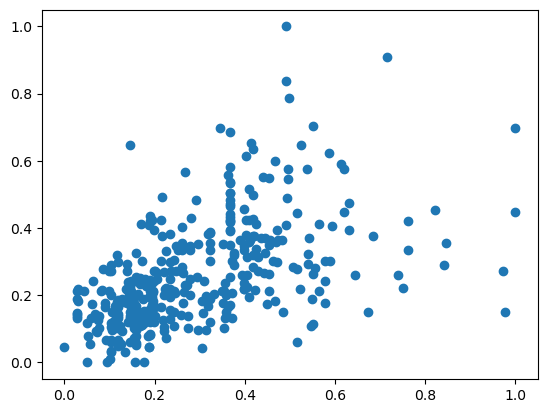

In [23]:
plt.scatter(df_train.area, df_train.price)

In [24]:
y_train = df_train.pop('price')
x_train = df_train

In [25]:
y_train.head()

359    0.169697
19     0.615152
159    0.321212
35     0.548133
28     0.575758
Name: price, dtype: float64

In [26]:
x_train = x_train.apply(pd.to_numeric, errors='coerce')

x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 381 entries, 359 to 520
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   area             381 non-null    float64
 1   bedrooms         381 non-null    float64
 2   bathrooms        381 non-null    float64
 3   stories          381 non-null    float64
 4   mainroad         381 non-null    int64  
 5   guestroom        381 non-null    int64  
 6   basement         381 non-null    int64  
 7   hotwaterheating  381 non-null    int64  
 8   airconditioning  381 non-null    int64  
 9   parking          381 non-null    float64
 10  prefarea         381 non-null    int64  
 11  semi-furnished   381 non-null    bool   
 12  unfurnished      381 non-null    bool   
dtypes: bool(2), float64(5), int64(6)
memory usage: 36.5 KB


In [27]:
x_train = x_train [['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea']]

In [28]:
import pandas as pd
import statsmodels.api as sm

# 1. Reset index to avoid alignment issues
x_train = x_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

# 2. Convert all X columns to numeric (coerce bad values to NaN)
x_train = x_train.apply(pd.to_numeric, errors='coerce')

# 3. Convert y to numeric
y_train = pd.to_numeric(y_train, errors='coerce')

# 4. Drop any NaNs introduced during conversion
df_clean = pd.concat([x_train, y_train], axis=1).dropna()
x_clean = df_clean[x_train.columns]
y_clean = df_clean[y_train.name]

# 5. Add intercept
x_clean = sm.add_constant(x_clean)

# 6. Fit model
lr = sm.OLS(y_clean, x_clean).fit()

print(lr.summary())


                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.673
Model:                            OLS   Adj. R-squared:                  0.663
Method:                 Least Squares   F-statistic:                     69.10
Date:                Mon, 29 Dec 2025   Prob (F-statistic):           1.34e-82
Time:                        18:02:42   Log-Likelihood:                 376.89
No. Observations:                 381   AIC:                            -729.8
Df Residuals:                     369   BIC:                            -682.5
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0008      0.018     

In [29]:
lr.params

const              0.000786
area               0.237417
bedrooms           0.053082
bathrooms          0.194447
stories            0.109401
mainroad           0.054240
guestroom          0.028472
basement           0.023391
hotwaterheating    0.088790
airconditioning    0.069305
parking            0.064211
prefarea           0.060437
dtype: float64

In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [31]:
# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
vif = pd.DataFrame()
vif['Features'] = x_train.columns
vif['VIF'] = [variance_inflation_factor(x_train.values, i) for i in range(x_train.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
1,bedrooms,6.28
4,mainroad,5.58
0,area,4.67
3,stories,2.68
9,parking,2.11
6,basement,2.01
8,airconditioning,1.76
2,bathrooms,1.65
10,prefarea,1.50
5,guestroom,1.47


In [32]:
X_train = x_train.drop(['bedrooms'], axis = 1 )

In [34]:
X_train_lm = sm.add_constant(X_train)
lr2 = sm.OLS(y_train, X_train_lm).fit()

print(lr2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.671
Model:                            OLS   Adj. R-squared:                  0.663
Method:                 Least Squares   F-statistic:                     75.59
Date:                Mon, 29 Dec 2025   Prob (F-statistic):           4.09e-83
Time:                        18:05:01   Log-Likelihood:                 375.84
No. Observations:                 381   AIC:                            -729.7
Df Residuals:                     370   BIC:                            -686.3
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0173      0.014     

In [35]:
# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
vif = pd.DataFrame()
vif['Features'] = X_train.columns
vif['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
0,area,4.52
3,mainroad,4.52
2,stories,2.22
8,parking,2.10
5,basement,1.87
7,airconditioning,1.76
1,bathrooms,1.60
9,prefarea,1.50
4,guestroom,1.46
6,hotwaterheating,1.12


In [36]:
y_train_pred = lr2.predict(X_train_lm)

<Axes: ylabel='Density'>

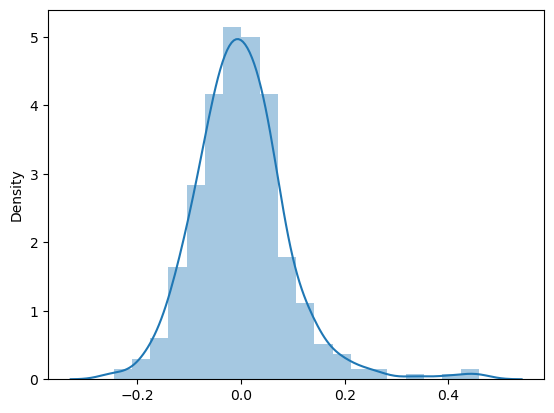

In [37]:
sns.distplot((y_train - y_train_pred), bins = 20)

In [38]:
num_var = ['area','bedrooms',  'bathrooms','stories','parking', 'price' ]

In [39]:
df_test[num_var] = scaler.transform (df_test[num_var])

In [40]:
df_test.describe()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
count,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000
mean,0.263176,0.298548,0.408537,0.158537,0.268293,0.865854,0.195122,0.347561,0.030488,0.353659,0.205285,0.237805
std,0.172077,0.211922,0.147537,0.281081,0.276007,0.341853,0.397508,0.477654,0.172452,0.479569,0.289322,0.427043
min,0.006061,-0.016367,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.142424,0.148011,0.400000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.226061,0.259724,0.400000,0.000000,0.333333,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.346970,0.397439,0.400000,0.500000,0.333333,1.000000,0.000000,1.000000,0.000000,1.000000,0.333333,0.000000
max,0.909091,1.263992,0.800000,1.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [41]:
y_test = df_test.pop('price')